In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8")

In [ ]:
# Path to the cleaned dataset folder
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Full path to the cleaned data folder
data_path = Path(r"C:\Users\POORVI NIDSOSHI\Desktop\ML PROJECT\project\data\cleaned")

# Dictionary mapping ticker names to files  
files = {
"AAPL": data_path / "Apple.csv",
"MSFT": data_path / "MSFT.csv",
"GOOGL": data_path / "google.csv",
"AMZN": data_path / "Amazon.csv",
"NVDA": data_path / "NVDIA.csv"
}

# Store datasets
dfs = {}

# Loop through each dataset and load it
for ticker, path in files.items():
    
    df = pd.read_csv(path)

    # Clean column names (remove hidden spaces)
    df.columns = df.columns.str.replace("\xa0","").str.strip()

    # Convert Date column to datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Sort data by date
    dfs[ticker] = df.sort_values("Date")

# Print loaded datasets
print("Datasets loaded:", list(dfs.keys()))

Datasets loaded: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']


In [5]:
# Check the number of rows and columns in each dataset

for ticker, df in dfs.items():
    
    print(ticker, df.shape)

AAPL (2767, 7)
MSFT (2766, 7)
GOOGL (2766, 7)
AMZN (2752, 7)
NVDA (2766, 7)


In [6]:
# Check if any missing values exist in the datasets

for ticker, df in dfs.items():
    
    print("\nMissing values in", ticker)
    print(df.isnull().sum())


Missing values in AAPL
Date         0
Open         0
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

Missing values in MSFT
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values in GOOGL
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values in AMZN
Date         0
Open         0
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

Missing values in NVDA
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [7]:
# Check if any missing values exist in the datasets

for ticker, df in dfs.items():
    
    print("\nMissing values in", ticker)
    print(df.isnull().sum())


Missing values in AAPL
Date         0
Open         0
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

Missing values in MSFT
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values in GOOGL
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values in AMZN
Date         0
Open         0
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

Missing values in NVDA
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [9]:
# Create dataframe for closing prices
prices = pd.DataFrame()

for ticker, df in dfs.items():

    # Remove duplicate dates if they exist
    df = df.drop_duplicates(subset="Date")

    # Set Date as index and select Close price
    df = df.set_index("Date")

    prices[ticker] = df["Close"]

# Show first few rows
prices.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA
Date,,,,,
2015-01-02,27.33,46.76,26.48,NaN,0.50
2015-01-05,26.56,46.33,25.97,NaN,0.49
2015-01-06,26.57,45.65,25.33,NaN,0.48
2015-01-07,26.94,46.23,25.26,NaN,0.48
2015-01-08,27.97,47.59,25.35,NaN,0.50


In [20]:
for ticker, df in dfs.items():
    print("\n", ticker)
    print(df.columns)


 AAPL
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

 MSFT
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

 GOOGL
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

 AMZN
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

 NVDA
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [12]:
# Create dataframe for closing prices
prices = pd.DataFrame()

for ticker, df in dfs.items():
    
    # remove duplicate dates
    df = df.drop_duplicates(subset="Date")

    # set Date as index
    df = df.set_index("Date")

    # store closing price
    prices[ticker] = df["Close"]

# show first rows
prices.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA
Date,,,,,
2015-01-02,27.33,46.76,26.48,NaN,0.50
2015-01-05,26.56,46.33,25.97,NaN,0.49
2015-01-06,26.57,45.65,25.33,NaN,0.48
2015-01-07,26.94,46.23,25.26,NaN,0.48
2015-01-08,27.97,47.59,25.35,NaN,0.50


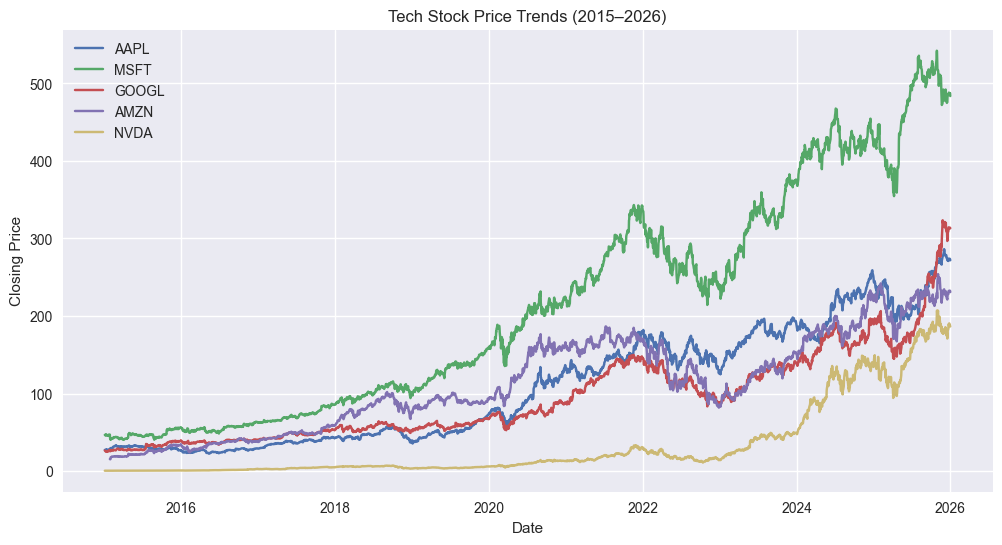

In [13]:
plt.figure(figsize=(12,6))

for col in prices.columns:
    plt.plot(prices.index, prices[col], label=col)

plt.title("Tech Stock Price Trends (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.show()

### Observation: Tech Stock Price Trends (2015–2026)

The line chart shows the historical closing prices of major technology companies including Apple (AAPL), Microsoft (MSFT), Google (GOOGL), Amazon (AMZN), and Nvidia (NVDA) from 2015 to 2026.

Overall, all technology stocks show a strong upward trend over the years, reflecting the growth of the technology sector. Microsoft shows the highest price growth and remains the most consistently increasing stock among the group. Apple and Google also demonstrate steady long-term growth with moderate fluctuations.

Amazon experienced significant growth especially after 2020, indicating increased demand for e-commerce and cloud services. Nvidia shows the most rapid acceleration in recent years, particularly after 2023, which reflects the strong market demand for AI and semiconductor technologies.

Although all stocks generally trend upward, noticeable volatility appears around 2020–2022, likely influenced by global economic conditions and market corrections. Overall, the visualization highlights that technology stocks have delivered strong long-term performance despite short-term fluctuations.

In [14]:
# Calculate daily percentage returns for each stock

returns = prices.pct_change().dropna()

# Display first few rows
returns.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA
Date,,,,,
2015-01-27,-0.035019,-0.092534,-0.029061,-0.009044,-0.057692
2015-01-28,0.056818,-0.034459,-0.016884,-0.009126,-0.020408
2015-01-29,0.031217,0.019908,0.001561,0.025658,0.020833
2015-01-30,-0.014800,-0.038324,0.047545,0.137267,-0.020408
2015-02-02,0.012632,0.021782,-0.010045,0.027637,0.020833


### Observation: Daily Returns

Daily returns represent the percentage change in stock prices from one trading day to the next. 
By calculating daily returns, we can better understand how volatile each stock is on a day-to-day basis.

Most returns are small and close to zero, indicating that stock prices usually change gradually. 
However, occasional larger spikes show periods of higher market volatility.

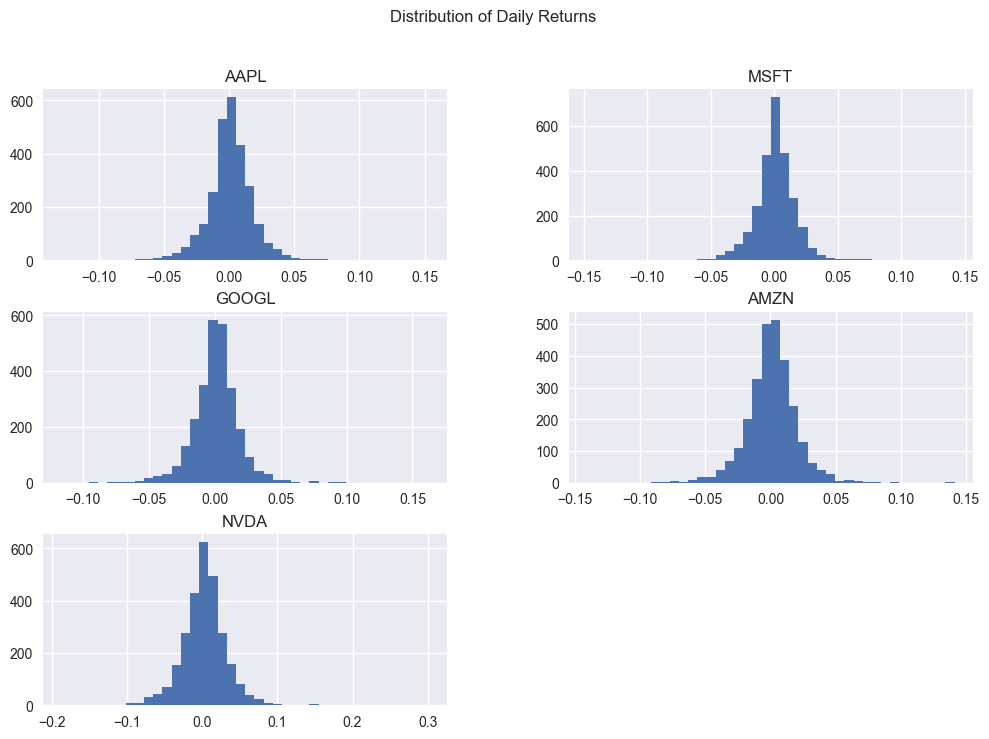

In [15]:
# Plot distribution of daily returns

returns.hist(figsize=(12,8), bins=40)

plt.suptitle("Distribution of Daily Returns")

plt.show()

### Observation: Return Distribution

The histogram shows the distribution of daily returns for each stock. 
Most returns are concentrated around zero, meaning daily price movements are generally small.

However, the spread of the distribution indicates that technology stocks can occasionally experience 
larger positive or negative returns. This reflects the inherent volatility in the technology sector.

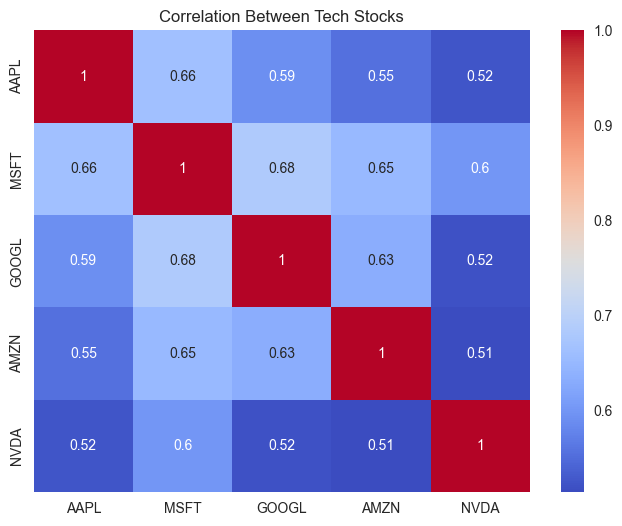

In [16]:
import seaborn as sns

# Compute correlation between stock returns
corr_matrix = returns.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Between Tech Stocks")

plt.show()

### Observation: Correlation Between Stocks

The correlation heatmap shows how strongly the daily returns of different stocks move together. 
A higher correlation means two stocks tend to move in the same direction.

Technology stocks typically show positive correlations with each other because they are influenced 
by similar market conditions, industry trends, and macroeconomic factors.

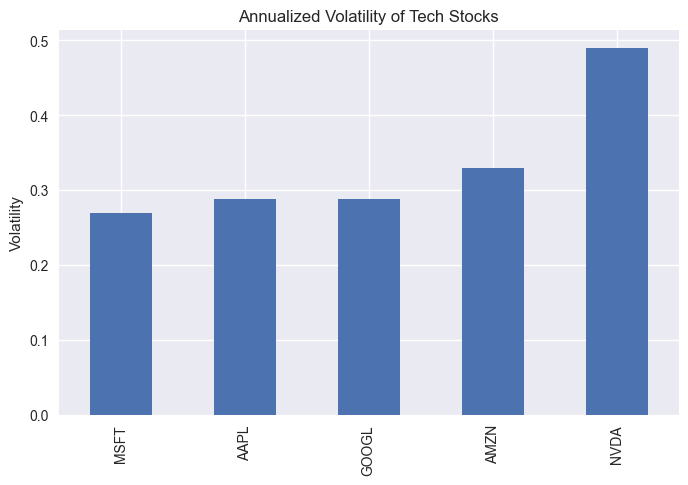

In [17]:
# Calculate annualized volatility (risk)

volatility = returns.std() * np.sqrt(252)

# Plot volatility
volatility.sort_values().plot(kind="bar", figsize=(8,5))

plt.title("Annualized Volatility of Tech Stocks")
plt.ylabel("Volatility")

plt.show()

### Observation: Stock Volatility

Volatility measures the level of risk associated with each stock. 
Stocks with higher volatility experience larger price fluctuations.

Technology companies often exhibit higher volatility compared to broader market indices 
because they operate in fast-changing and innovation-driven industries.

In [18]:
# Create moving averages for each stock

features = prices.copy()

# 20-day moving average
features["MA20"] = prices.mean(axis=1).rolling(20).mean()

# 50-day moving average
features["MA50"] = prices.mean(axis=1).rolling(50).mean()

features.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA,MA20,MA50
Date,,,,,,,
2015-01-02,27.33,46.76,26.48,NaN,0.50,NaN,NaN
2015-01-05,26.56,46.33,25.97,NaN,0.49,NaN,NaN
2015-01-06,26.57,45.65,25.33,NaN,0.48,NaN,NaN
2015-01-07,26.94,46.23,25.26,NaN,0.48,NaN,NaN
2015-01-08,27.97,47.59,25.35,NaN,0.50,NaN,NaN
